### Simple Mean Variance Simulation on S&P 500 Index
#### This exercise will act as the baseline and an intuition for Monte Carlo simulation

**Discrete form**
$$Price_t = Price_{t-1} * [1 + (\mu + Z*\sigma)]$$
**Continuous form, also known as, geometric form**
$$Price_t = Price_{t-1} * e^{\mu + Z*\sigma}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Initial Values

In [2]:
daily_mean = 0.0005761568787138174
daily_std = 0.012512872309859016
num_years = 500 #As in 500 Years
num_days = 252  #Roughly 252 Trading days per year
initial_price = 6845.50 #Closing price on 12/31/2025 

## Generate normally distributed random numbers for the simulation

In [3]:
random_values = np.random.standard_normal((num_days, num_years)) #Standard normal distribution
print(random_values.shape)

(252, 500)


## Generate Price Path - Loop
Best for understanding whats happening at each step

In [4]:
price_paths = np.zeros((num_days, num_years))
price_paths[0] = initial_price
for t in range(1, num_days):
    # Discrete
    price_paths[t] = price_paths[t-1] * ( 1 + daily_mean + random_values[t] * daily_std) #If standard normal values were generated
    ##Continuous
    # price_paths[t] = price_paths[t-1] * np.exp(daily_mean + random_values[t] * daily_std) ##If standard normal values were generated
    

## Generate Price Path - Vectorize
Best for generating a vast number of days like for instance a million days. Probably unnecessary 

In [6]:
## Discrete
# price_paths = (1 + daily_mean + random_values * daily_std) #Vectorise (1+ mu + Z*sigma) based on standard normal

## Continuous or geometric version
# price_paths = np.exp(daily_mean + random_values * daily_std) #Vectorise (1+ mu + Z*sigma) based on standard normal

# price_paths[0] = initial_price #Set initial value at the head of each simulation
# price_paths = price_paths.cumprod(axis=0)

## Plot Simulation

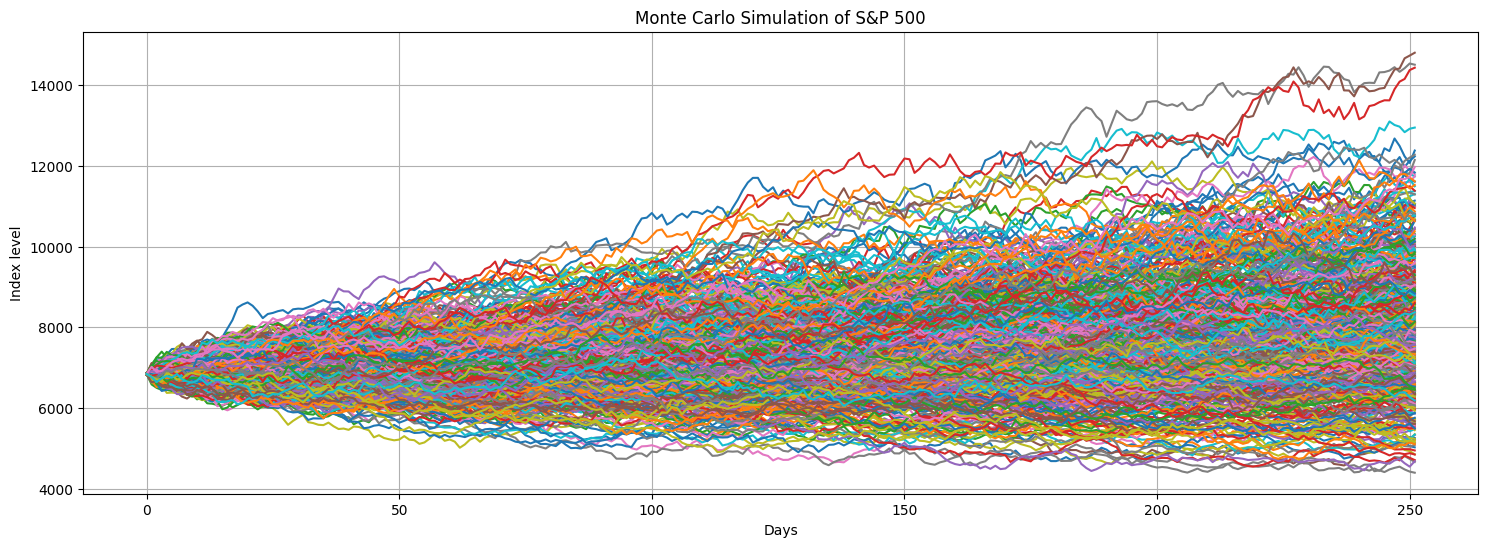

In [7]:
plt.figure(figsize=(18, 6))
plt.plot(price_paths)
plt.title(f'Monte Carlo Simulation of S&P 500')
plt.xlabel('Days')
plt.ylabel('Index level')
plt.grid(True)

## Histogram of the terminal values(last day) of the simulation

End of period mean 7806.9676096243
End of period std 1461.4287019173782


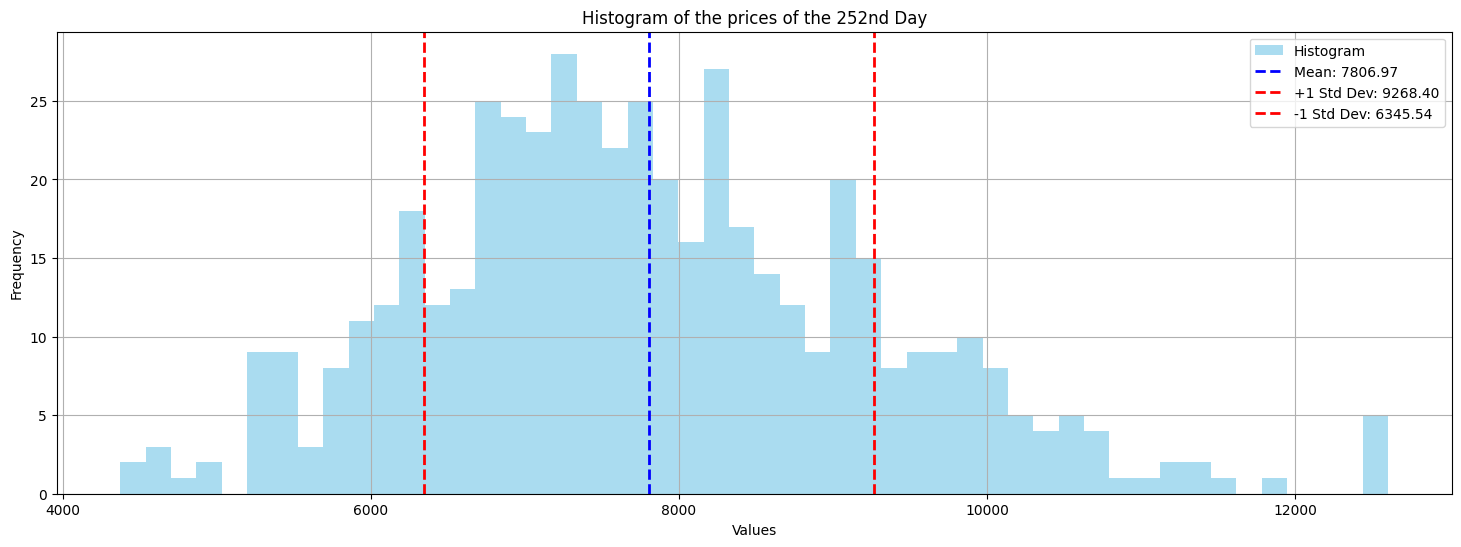

In [16]:
mean_val = np.mean(price_paths[251]) #Mean or average of the prices on the 252nd day
std_val = np.std(price_paths[251])   #STDEV or average of the prices on the 252nd day
plt.figure(figsize=(18, 6))
plt.hist(price_paths[251], bins=50, color='skyblue', alpha=0.7, label='Histogram')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(True)
plt.title("Histogram of the prices of the 252nd Day")
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(mean_val + std_val, color='red', linestyle='dashed', linewidth=2, label=f'+1 Std Dev: {mean_val + std_val:.2f}')
plt.axvline(mean_val - std_val, color='red', linestyle='dashed', linewidth=2, label=f'-1 Std Dev: {mean_val - std_val:.2f}')
plt.legend()

print(f"End of period mean {mean_val}")
print(f"End of period std {std_val}")

## This of course is a naive approach but there is more to it
- It's observed that the market as a positive long term trend however there are shocks to that 
- It is also observed that there is a drag effect on that drift caused by volatility
- A 1.% round trip on 100, 100*(1.01)*(.99) = 99.99
- A 20% round trip on 100, 100*(1.20)*(.80) = 96

## We can see all of this in Geometric Brownian Simulation